## L'Eua Claire
## Group 5
## Team Members
| Name | Student's ID |
|---|---|
| Rith Theary | e20231141 |
| Roeurn Phannet | e20230799 |
| Meth Sreyka | e20230172 |

> **Dataset:** Water body monitoring data 2017–2022  
> **Target:** `Fecal_Coliform`

**Column naming contract (used in both notebooks):**

| Original (after averaging) | Saved in CSV |
|---|---|
| Temperature | `Temperature` |
| Dissolved Oxygen | `DO` ← renamed here |
| pH | `pH` |
| Conductivity | `Conductivity` → `Conductivity_log` |
| BOD | `BOD` → `BOD_log` |
| Nitrate_Nitrite | `Nitrate_Nitrite` → `Nitrate_Nitrite_log` |
| Fecal_Coliform | `Fecal_Coliform` (original kept; **target**) |
| Total_Coliform | `Total_Coliform` (EDA only dropped in ML) |

---

## Imports

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
from scipy.stats import mstats
from matplotlib.patches import Patch

plt.style.use('ggplot')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
print("Libraries loaded.")

Libraries loaded.


## Load Raw Data

In [89]:
df = pd.read_csv(r'..\Dataset\dataset_2017-2022.csv')
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Loaded: 2,804 rows × 21 columns


,STN Code,Name of Monitoring Location,Type Water Body,State Name,Min Temperature,Max Temperature,Min Dissolved Oxygen,Max Dissolved Oxygen,Min pH,Max pH,Min Conductivity,Max Conductivity,Min BOD,Max BOD,Min Nitrate N + Nitrite N,Max Nitrate N + Nitrite N,Min Fecal Coliform,Max Fecal Coliform,Min Total Coliform,Max Total Coliform,Year
0,1790.00,"PULICATE LAKE , NELLORE \nDIST.",LAKE,ANDHRA \nPRADESH,27,28.00,5.1,6.9,7.1,8.50,3270.00,156600.00,1,2.3,0.65,6.90,2,2,800,1600,2017
1,2353.00,"KONDACHARLA-AAVA LAKE, \nPARAWADA PHARMA CITY,...",LAKE,ANDHRA \nPRADESH,24,28.00,5.9,6.8,6.9,8.40,597.00,1034.00,1.3,2.3,1.16,3.36,11,29,350,2400,2017
2,2205.00,"MER BEEL AT MADHABPUR, \nASSAM",LAKE,ASSAM,20,27.00,2.2,7.2,5.7,7.00,50.00,128.00,1,16.2,0.1,1.70,300,2000,360,6400,2017
3,2206.00,"DALONI BEEL NEAR \nJOGIGHOPA, ASSAM",LAKE,ASSAM,22,36.00,5.1,6,6.6,7.80,54.00,153.00,0.9,2.8,0.1,1.40,300,1200,300,5300,2017
4,1263.00,ELANGABEEL SYSTEM POND \n(CONNECTED TO R. KOLA...,POND,ASSAM,22,34.00,0.7,4.6,6.8,8.40,263.00,972.00,4.5,14.7,0.8,5.70,1100,3500,730,21000,2017


## Data Understanding

In [90]:
print("Shape:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)
print("\nBasic statistics:")
df.describe()

Shape: (2804, 21)

Column dtypes:
STN Code                       float64
Name of Monitoring Location     object
Type Water Body                 object
State Name                      object
Min Temperature                 object
Max Temperature                float64
Min Dissolved Oxygen            object
Max Dissolved Oxygen            object
Min pH                          object
Max pH                         float64
Min Conductivity               float64
Max Conductivity               float64
Min BOD                         object
Max BOD                         object
Min Nitrate N + Nitrite N       object
Max Nitrate N + Nitrite N      float64
Min Fecal Coliform              object
Max Fecal Coliform              object
Min Total Coliform              object
Max Total Coliform              object
Year                             int64
dtype: object

Basic statistics:


,STN Code,Max Temperature,Max pH,Min Conductivity,Max Conductivity,Max Nitrate N + Nitrite N,Year
count,2795.00,2777.00,2794.00,2789.00,2789.00,2789.00,2804.00
mean,3294.21,29.22,8.11,735.29,2372.29,7.12,2019.85
std,1057.81,3.74,0.54,2034.83,8117.40,17.38,1.64
min,1215.00,7.40,6.50,0.00,27.00,0.00,2017.00
25%,2344.00,27.00,7.70,178.00,395.00,1.12,2019.00
50%,3593.00,29.00,8.10,368.00,890.00,2.79,2020.00
75%,4178.50,32.00,8.40,706.00,1593.00,7.60,2021.00
max,5291.00,42.00,11.10,31100.00,181400.00,600.73,2022.00


## Data Preparation

| Sub-step | Action |
|---|---|
| 1 | Select & type-convert columns |
| 2 | Average Min/Max → single columns, rename to underscore convention |
| 3 | Fill missing values, drop duplicates |
| 4 | Filter low-record states (≥50 records/year) |
| 5 | Domain-based impossible value removal |
| 6 | Log transform skewed features → `_log` columns |

In [91]:
# Select columns
df = df[[
    'Type Water Body', 'State Name',
    'Min Temperature',           'Max Temperature',
    'Min Dissolved Oxygen',      'Max Dissolved Oxygen',
    'Min pH',                    'Max pH',
    'Min Conductivity',          'Max Conductivity',
    'Min BOD',                   'Max BOD',
    'Min Nitrate N + Nitrite N', 'Max Nitrate N + Nitrite N',
    'Min Fecal Coliform',        'Max Fecal Coliform',
    'Min Total Coliform',        'Max Total Coliform',
    'Year'
]].copy()

# Strip whitespace + convert numeric
df = df.replace({',': ''}, regex=True)
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.strip()

num_raw = [c for c in df.columns if c not in ['Type Water Body', 'State Name', 'Year']]
for col in num_raw:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Selected & converted:", df.shape)

Selected & converted: (2804, 19)


In [92]:
# state clean
df["State Name"] = df["State Name"].str.replace("\n", "", regex=False).str.strip()

In [93]:
# Average Min/Max → clean column names (all underscores, no spaces)
df['Temperature']     = (df['Min Temperature']               + df['Max Temperature'])             / 2
df['DO']              = (df['Min Dissolved Oxygen']          + df['Max Dissolved Oxygen'])        / 2
df['pH']              = (df['Min pH']                        + df['Max pH'])                      / 2
df['Conductivity']    = (df['Min Conductivity']              + df['Max Conductivity'])            / 2
df['BOD']             = (df['Min BOD']                       + df['Max BOD'])                     / 2
df['Nitrate_Nitrite'] = (df['Min Nitrate N + Nitrite N']     + df['Max Nitrate N + Nitrite N'])   / 2
df['Fecal_Coliform']  = (df['Min Fecal Coliform']            + df['Max Fecal Coliform'])          / 2
df['Total_Coliform']  = (df['Min Total Coliform']            + df['Max Total Coliform'])          / 2

# Rename categorical column no spaces
df.rename(columns={'Type Water Body': 'Water_Body_Type', 'State Name': 'State_Name'}, inplace=True)

# Drop all Min/Max raw columns
df.drop(columns=[c for c in df.columns if c.startswith('Min ') or c.startswith('Max ')],
        inplace=True)

print("Columns after averaging:", df.columns.tolist())
df.head()

Columns after averaging: ['Water_Body_Type', 'State_Name', 'Year', 'Temperature', 'DO', 'pH', 'Conductivity', 'BOD', 'Nitrate_Nitrite', 'Fecal_Coliform', 'Total_Coliform']


,Water_Body_Type,State_Name,Year,Temperature,DO,pH,Conductivity,BOD,Nitrate_Nitrite,Fecal_Coliform,Total_Coliform
0,LAKE,ANDHRA PRADESH,2017,27.50,6.00,7.80,79935.00,1.65,3.78,2.00,1200.00
1,LAKE,ANDHRA PRADESH,2017,26.00,6.35,7.65,815.50,1.80,2.26,20.00,1375.00
2,LAKE,ASSAM,2017,23.50,4.70,6.35,89.00,8.60,0.90,1150.00,3380.00
3,LAKE,ASSAM,2017,29.00,5.55,7.20,103.50,1.85,0.75,750.00,2800.00
4,POND,ASSAM,2017,28.00,2.65,7.60,617.50,9.60,3.25,2300.00,10865.00


In [94]:
df["Water_Body_Type"] = df["Water_Body_Type"].str.upper()

In [95]:
df["Water_Body_Type"].unique()

array(['LAKE', 'POND', 'TANK', 'WETLAND', nan], dtype=object)

In [96]:
# Fill missing values + drop duplicates
print("Missing values:")
print(df.isna().sum())

for col in ['Water_Body_Type', 'State_Name']:
    df[col] = df[col].fillna(df[col].mode()[0])

FEAT_COLS = ['Temperature', 'DO', 'pH', 'Conductivity',
             'BOD', 'Nitrate_Nitrite', 'Fecal_Coliform', 'Total_Coliform']
for col in FEAT_COLS:
    df[col] = df[col].fillna(df[col].median())

before = len(df)
df.drop_duplicates(inplace=True)
print(f"\nDuplicates removed: {before - len(df)}")
print(f"Shape: {df.shape}")

Missing values:
Water_Body_Type     8
State_Name          8
Year                0
Temperature        27
DO                 24
pH                 11
Conductivity       15
BOD                29
Nitrate_Nitrite    33
Fecal_Coliform     26
Total_Coliform     90
dtype: int64

Duplicates removed: 7
Shape: (2797, 11)


In [97]:
df["State_Name"].unique()

array(['ANDHRA PRADESH', 'ASSAM', 'BIHAR', 'CHANDIGARH', 'CHHATTISGARH',
       'GOA', 'GUJARAT', 'HARYANA', 'HIMACHAL PRADESH', 'KARNATAKA',
       'KERALA', 'LAKSHADWEEP', 'MADHYA PRADESH', 'MEGHALAYA', 'ODISHA',
       'PUDUCHERRY', 'PUNJAB', 'RAJASTHAN', 'TAMIL NADU', 'TELANGANA',
       'TRIPURA', 'UTTAR PRADESH', 'WEST BENGAL', 'DELHI', 'MANIPUR',
       'UTTARAKHAND', 'SIKKIM'], dtype=object)

In [98]:
# Domain-based impossible value removal (ONCE, here in EDA)
DOMAIN_LIMITS = {
    'Temperature'     : (0,    45),
    'DO'              : (0,    20),
    'pH'              : (0,    14),
    'Conductivity'    : (0,  5000),
    'BOD'             : (0,  1000),
    'Nitrate_Nitrite' : (0,   100),
    'Fecal_Coliform'  : (0,  1e7),
    'Total_Coliform'  : (0,  1e7),
}

before = len(df)
for col, (lo, hi) in DOMAIN_LIMITS.items():
    mask = (df[col] < lo) | (df[col] > hi)
    if mask.sum():
        print(f"  {col:20s}: removed {mask.sum():,} impossible values")
    df = df[~mask]

print(f"\nRows before: {before:,}  →  after: {len(df):,}")
print("Domain cleaning done.")

  DO                  : removed 5 impossible values
  Conductivity        : removed 111 impossible values
  Nitrate_Nitrite     : removed 2 impossible values
  Fecal_Coliform      : removed 22 impossible values
  Total_Coliform      : removed 40 impossible values

Rows before: 2,797  →  after: 2,617
Domain cleaning done.


In [99]:
# Log transform skewed features
# Rule: create _log columns alongside originals.
# 'Fecal_Coliform' original is kept intact it is the target.
# DO uses sqrt (already close to normal, not log).

LOG_COLS = ['Conductivity', 'BOD', 'Nitrate_Nitrite', 'Total_Coliform']
for col in LOG_COLS:
    df[col + '_log'] = np.log1p(df[col])

# Fecal_Coliform log used only for EDA charts; ML will train on this but target stays original
df['Fecal_Coliform_log'] = np.log1p(df['Fecal_Coliform'])

# DO sqrt reduces moderate right skew better than log1p
df['DO_sqrt'] = np.sqrt(df['DO'].clip(lower=0))

print("Transformed columns added:")
new_cols = [c + '_log' for c in LOG_COLS] + ['Fecal_Coliform_log', 'DO_sqrt']
print(new_cols)
print("\nSkewness transformed versions:")
print(df[new_cols].skew().sort_values(ascending=False).round(2))

Transformed columns added:
['Conductivity_log', 'BOD_log', 'Nitrate_Nitrite_log', 'Total_Coliform_log', 'Fecal_Coliform_log', 'DO_sqrt']

Skewness transformed versions:
Nitrate_Nitrite_log    0.82
BOD_log                0.79
Total_Coliform_log     0.79
Fecal_Coliform_log     0.50
Conductivity_log      -0.69
DO_sqrt               -1.18
dtype: float64


## Outlier Analysis (EDA visualisation only)

In [ ]:
# IQR outlier count per feature for understanding, NOT for removal here
outlier_counts = {}
for col in FEAT_COLS:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    n      = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    outlier_counts[col] = n

ol_df = (pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['Outlier_Count'])
         .sort_values('Outlier_Count', ascending=True))
print(ol_df)

                 Outlier_Count
DO                          19
pH                          39
Conductivity                99
Temperature                130
BOD                        230
Nitrate_Nitrite            256
Fecal_Coliform             496
Total_Coliform             565


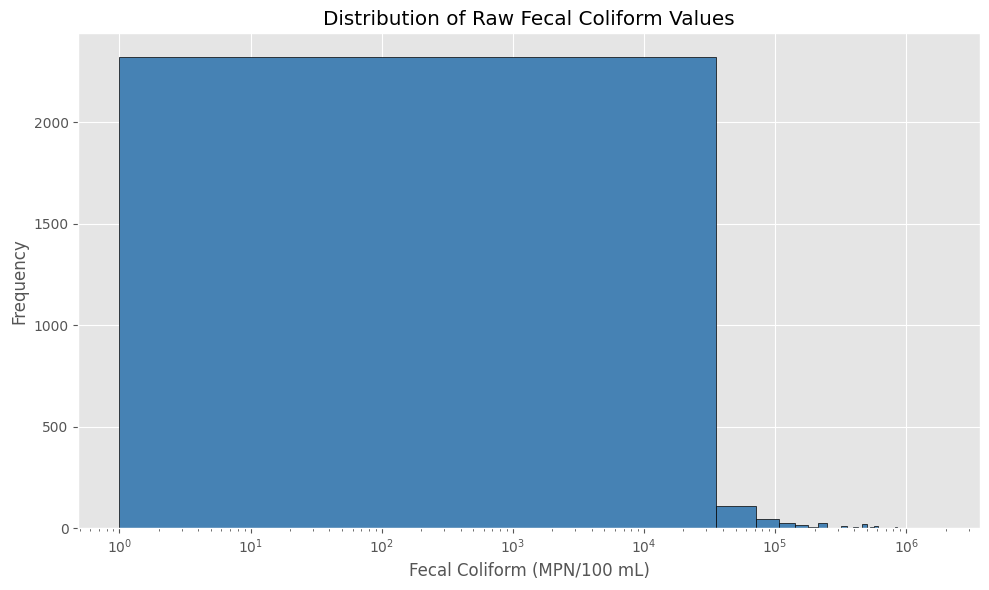

In [101]:
fc = pd.to_numeric(df["Fecal_Coliform"], errors="coerce")

# Remove missing and non-positive values
fc = fc.dropna()
fc = fc[fc > 0]

plt.figure(figsize=(10, 6))

plt.hist(
    fc,
    bins=50,
    color='steelblue',
    edgecolor='black'
)

plt.xscale('log')

plt.xlabel('Fecal Coliform (MPN/100 mL)')
plt.ylabel('Frequency')

plt.title('Distribution of Raw Fecal Coliform Values')

plt.grid(True)

plt.tight_layout()
plt.show()

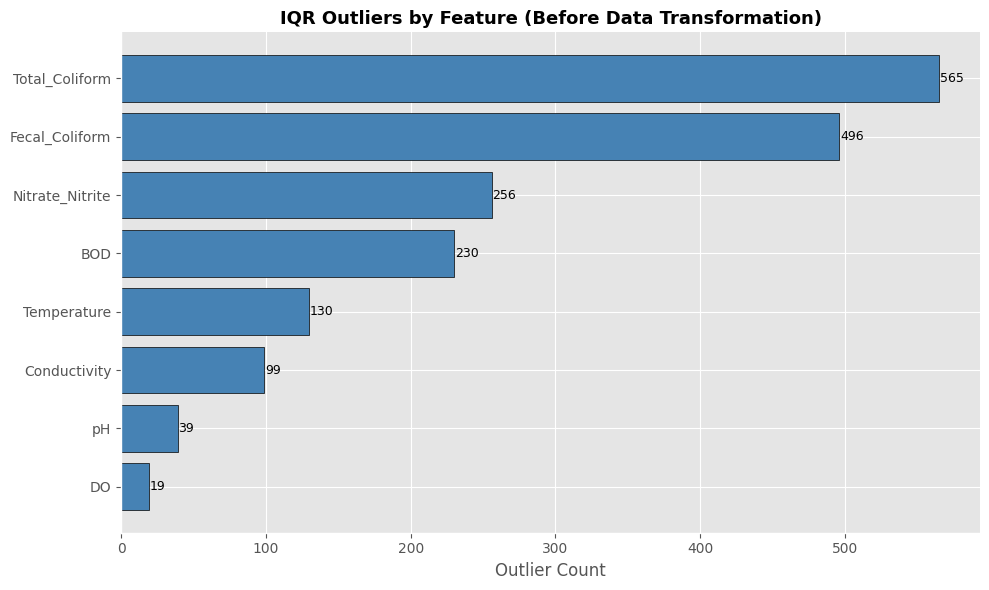

In [102]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    ol_df.index,
    ol_df['Outlier_Count'],
    color='steelblue',
    edgecolor='black'
)

for bar in bars:
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f'{int(bar.get_width())}',
        va='center',
        fontsize=9
    )

ax.set_title(
    'IQR Outliers by Feature (Before Data Transformation)',
    fontsize=13,
    fontweight='bold'
)

ax.set_xlabel('Outlier Count')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

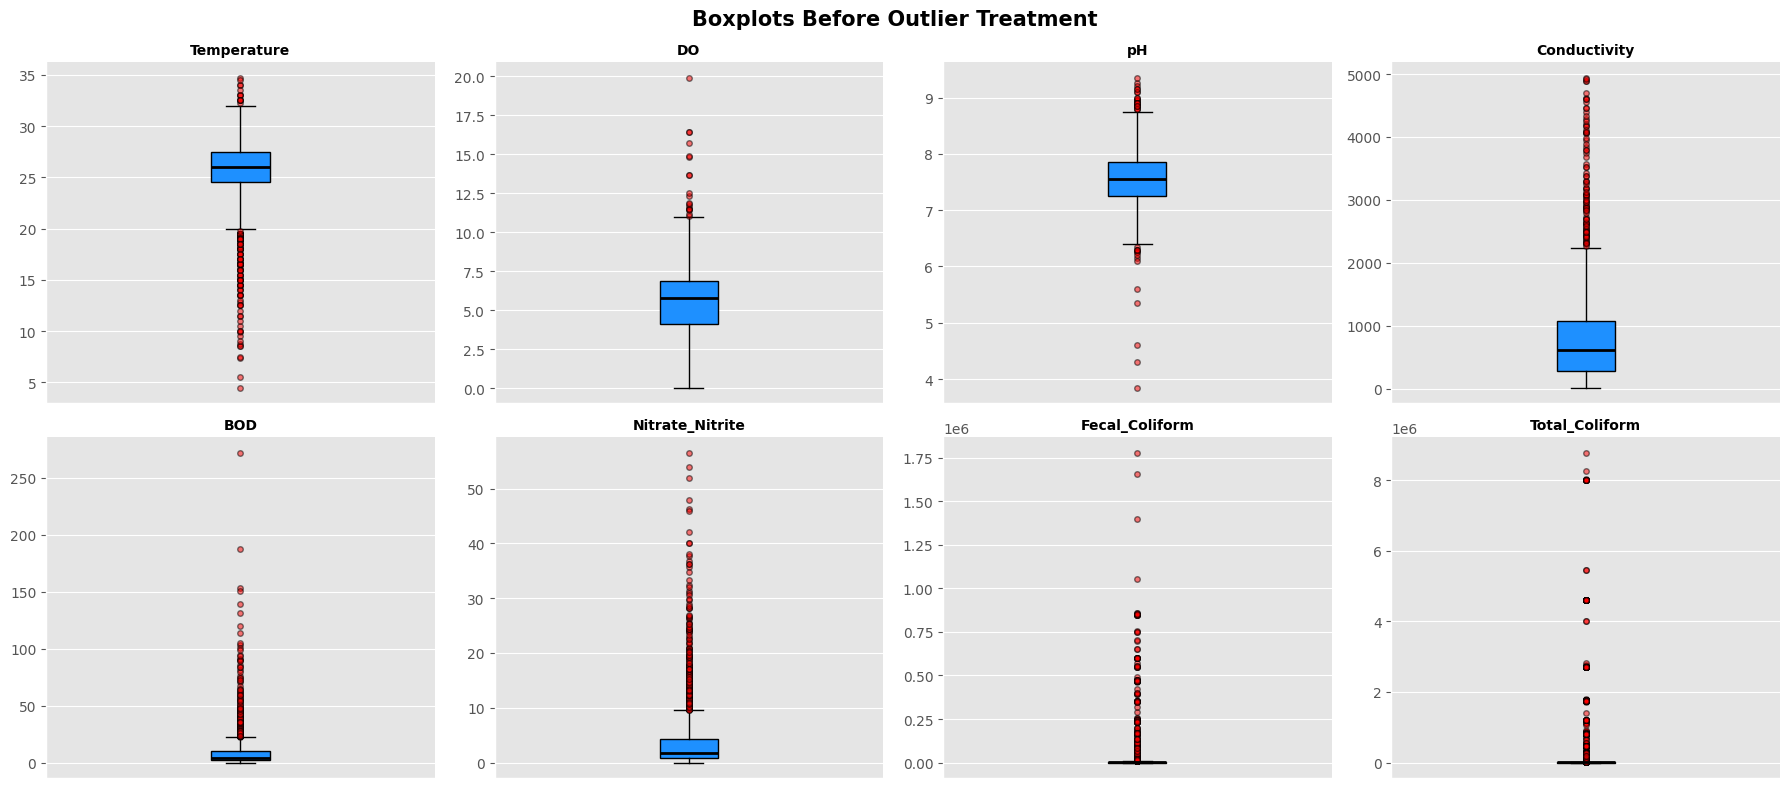

In [103]:
# Boxplots before data transformation
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(FEAT_COLS):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='dodgerblue'),
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markersize=4,
                                    markerfacecolor='red', alpha=0.5))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xticks([])
    axes[i].spines['top'].set_visible(False); axes[i].spines['right'].set_visible(False)
fig.suptitle('Boxplots Before Outlier Treatment', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

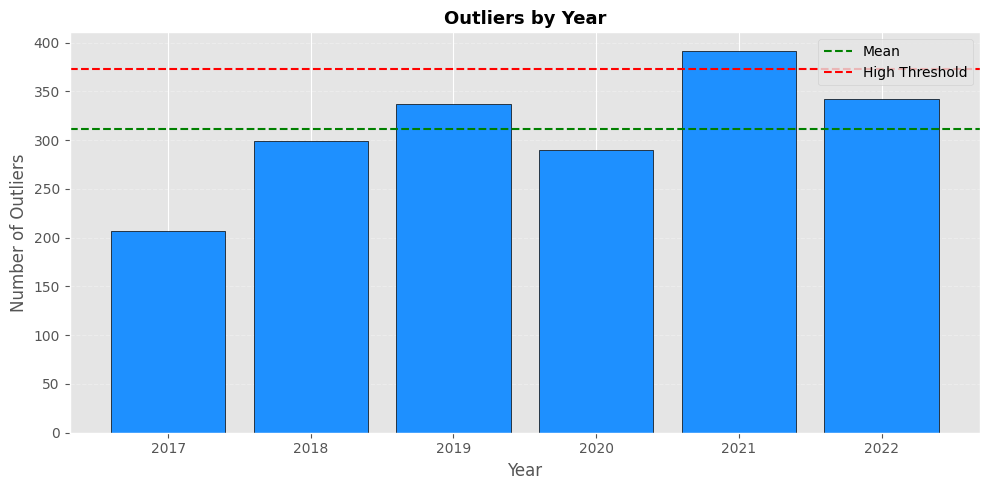

In [104]:
# Outlier count by Year
year_ol = []
for year, grp in df.groupby('Year'):
    total = sum(((grp[col] < grp[col].quantile(0.25) - 1.5*(grp[col].quantile(0.75)-grp[col].quantile(0.25))) |
                 (grp[col] > grp[col].quantile(0.75) + 1.5*(grp[col].quantile(0.75)-grp[col].quantile(0.25)))).sum()
                for col in FEAT_COLS)
    year_ol.append([year, total])

yr_df   = pd.DataFrame(year_ol, columns=['Year','Outliers'])
mean_v  = yr_df['Outliers'].mean(); std_v = yr_df['Outliers'].std()

plt.figure(figsize=(10, 5))
plt.bar(yr_df['Year'], yr_df['Outliers'], color='dodgerblue', edgecolor='black')
plt.axhline(mean_v,         color='green', linestyle='--', label='Mean')
plt.axhline(mean_v + std_v, color='red',   linestyle='--', label='High Threshold')
plt.title('Outliers by Year', fontsize=13, fontweight='bold')
plt.xlabel('Year'); plt.ylabel('Number of Outliers')
plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout(); plt.show()

## Handle Outlier (Winsorize only)

> **Key principle:** `df` is the EDA dataframe — **never modified after this cell**.  
> We create `df_ml` as a separate copy.  
> Treatment = simple Winsorize at p1/p99. No IQR+Z hybrid (domain rules already removed impossible values).

| Feature | Treatment | Reason |
|---|---|---|
| Temperature | Winsorize p1/p99 | Real but rare spikes |
| DO | Winsorize p1/p99 | Aeration/bloom events |
| pH | Winsorize p1/p99 | Sensor noise; extreme values already removed by domain rules |
| Conductivity | Winsorize p1/p99 | Saline intrusion |
| BOD | Winsorize p1/p99 | Industrial discharge |
| Nitrate_Nitrite | Winsorize p1/p99 | Agricultural runoff |
| Fecal_Coliform | **KEEP**  | Target variable  never alter |
| Total_Coliform | Keep | Excluded from ML features |

In [114]:
# Create ML copy (df is NEVER modified again after this)
df_ml = df.copy()
print(f"df_ml created: {df_ml.shape}")
 
WINSORIZE_COLS = ['Temperature', 'DO', 'pH', 'Conductivity', 'BOD', 'Nitrate_Nitrite']
LIMITS         = [0.01, 0.01]
 
for col in WINSORIZE_COLS:
    df_ml[col] = mstats.winsorize(df_ml[col], limits=LIMITS)
    # Also update the _log version if it exists
    log_col = col + '_log'
    if log_col in df_ml.columns:
        df_ml[log_col] = np.log1p(df_ml[col])   # recalculate from winsorized base
 
# Recalculate DO_sqrt from winsorized DO
df_ml['DO_sqrt'] = np.sqrt(df_ml['DO'].clip(lower=0))
 
print("\nWinsorizing applied to:", WINSORIZE_COLS)
print("_log and DO_sqrt recalculated from winsorized values.")
print(f"\ndf_ml shape: {df_ml.shape}")
print("df (EDA copy) is untouched:", df.shape)

df_ml created: (2617, 17)

Winsorizing applied to: ['Temperature', 'DO', 'pH', 'Conductivity', 'BOD', 'Nitrate_Nitrite']
_log and DO_sqrt recalculated from winsorized values.

df_ml shape: (2617, 17)
df (EDA copy) is untouched: (2617, 17)


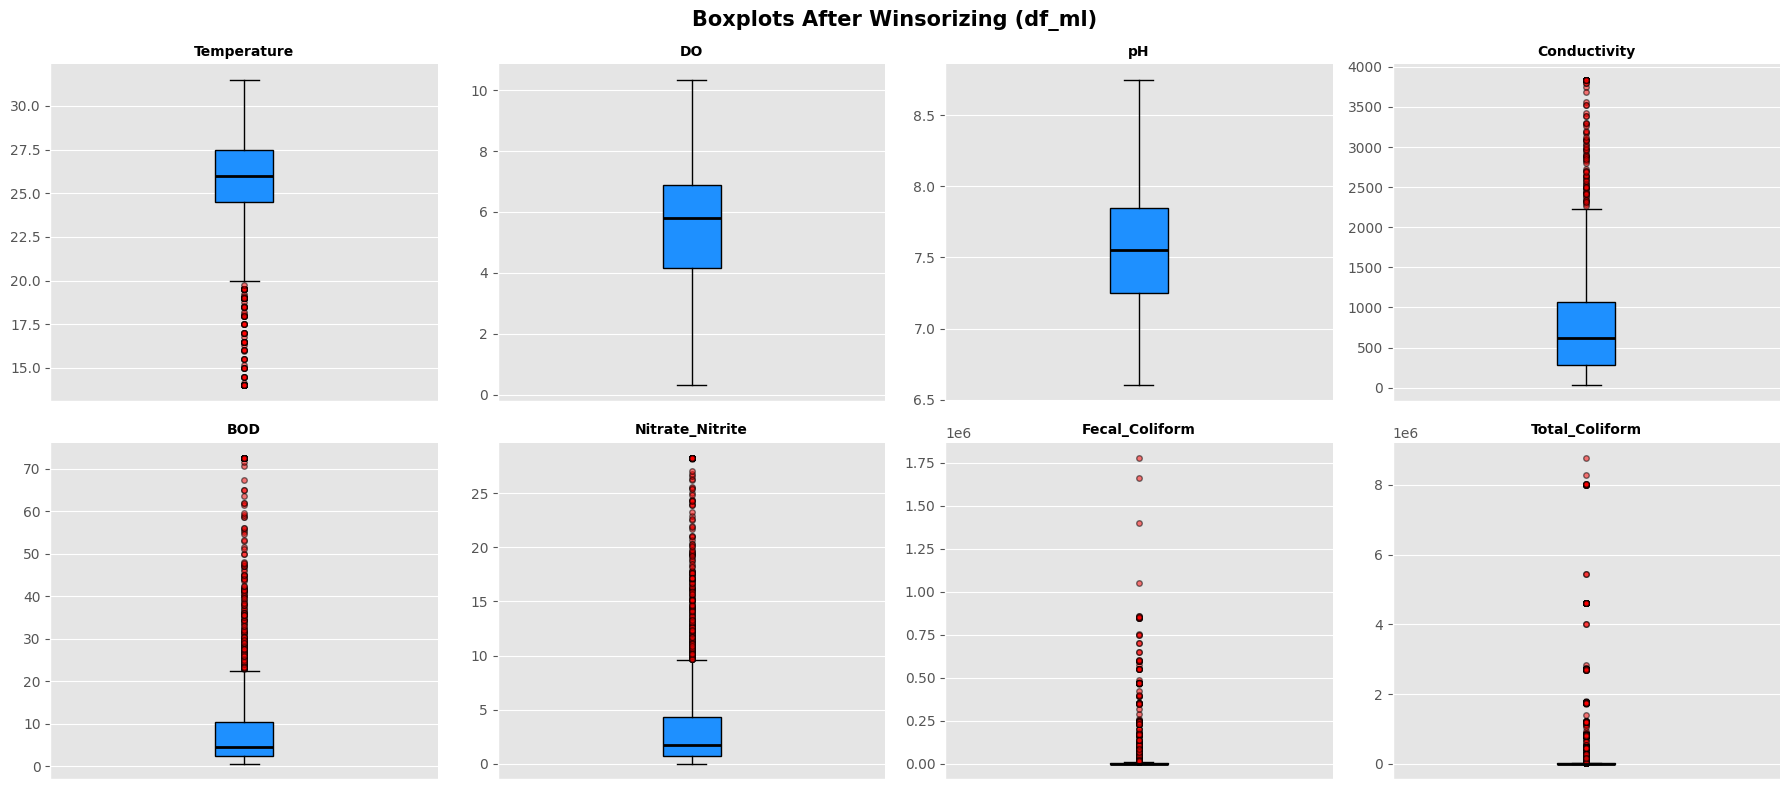

In [112]:
# Boxplots after handling outliers with winsorizing (on df_ml)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(FEAT_COLS):
    axes[i].boxplot(df_ml[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='dodgerblue'),
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markersize=4,
                                    markerfacecolor='red', alpha=0.5))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xticks([])
    axes[i].spines['top'].set_visible(False); axes[i].spines['right'].set_visible(False)
fig.suptitle('Boxplots After Winsorizing (df_ml)', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the Maske

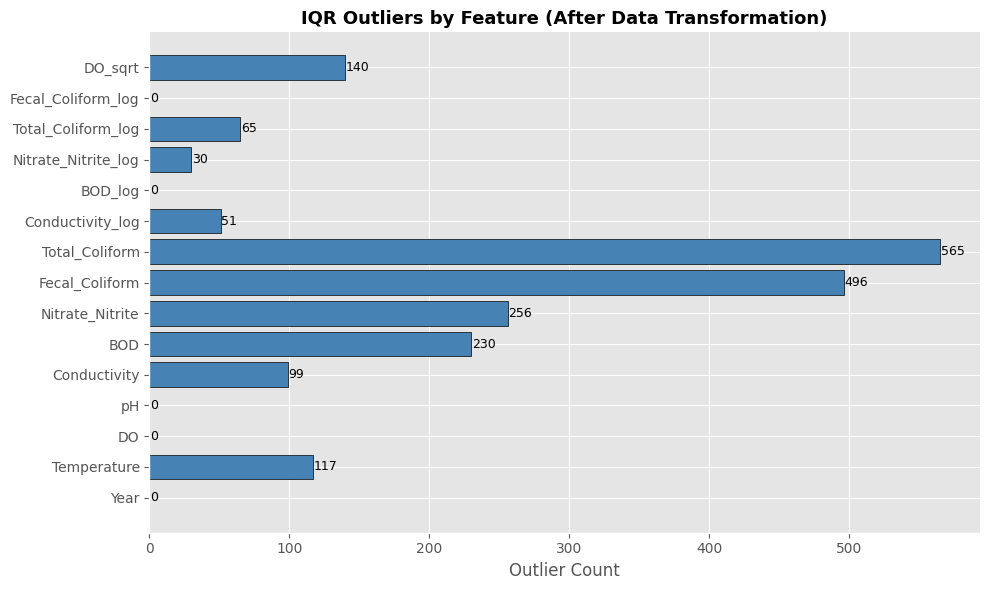

In [116]:
ol_df_after = compute_outliers(df_ml)
 
fig, ax = plt.subplots(figsize=(10, 6))
 
bars = ax.barh(
    ol_df_after.index,
    ol_df_after['Outlier_Count'],
    color='steelblue',
    edgecolor='black'
)
 
for bar in bars:
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())}',
        va='center',
        fontsize=9
    )
 
ax.set_title(
    'IQR Outliers by Feature (After Data Transformation)',
    fontsize=13,
    fontweight='bold'
)
ax.set_xlabel('Outlier Count')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Distributions (Before & After Transform)

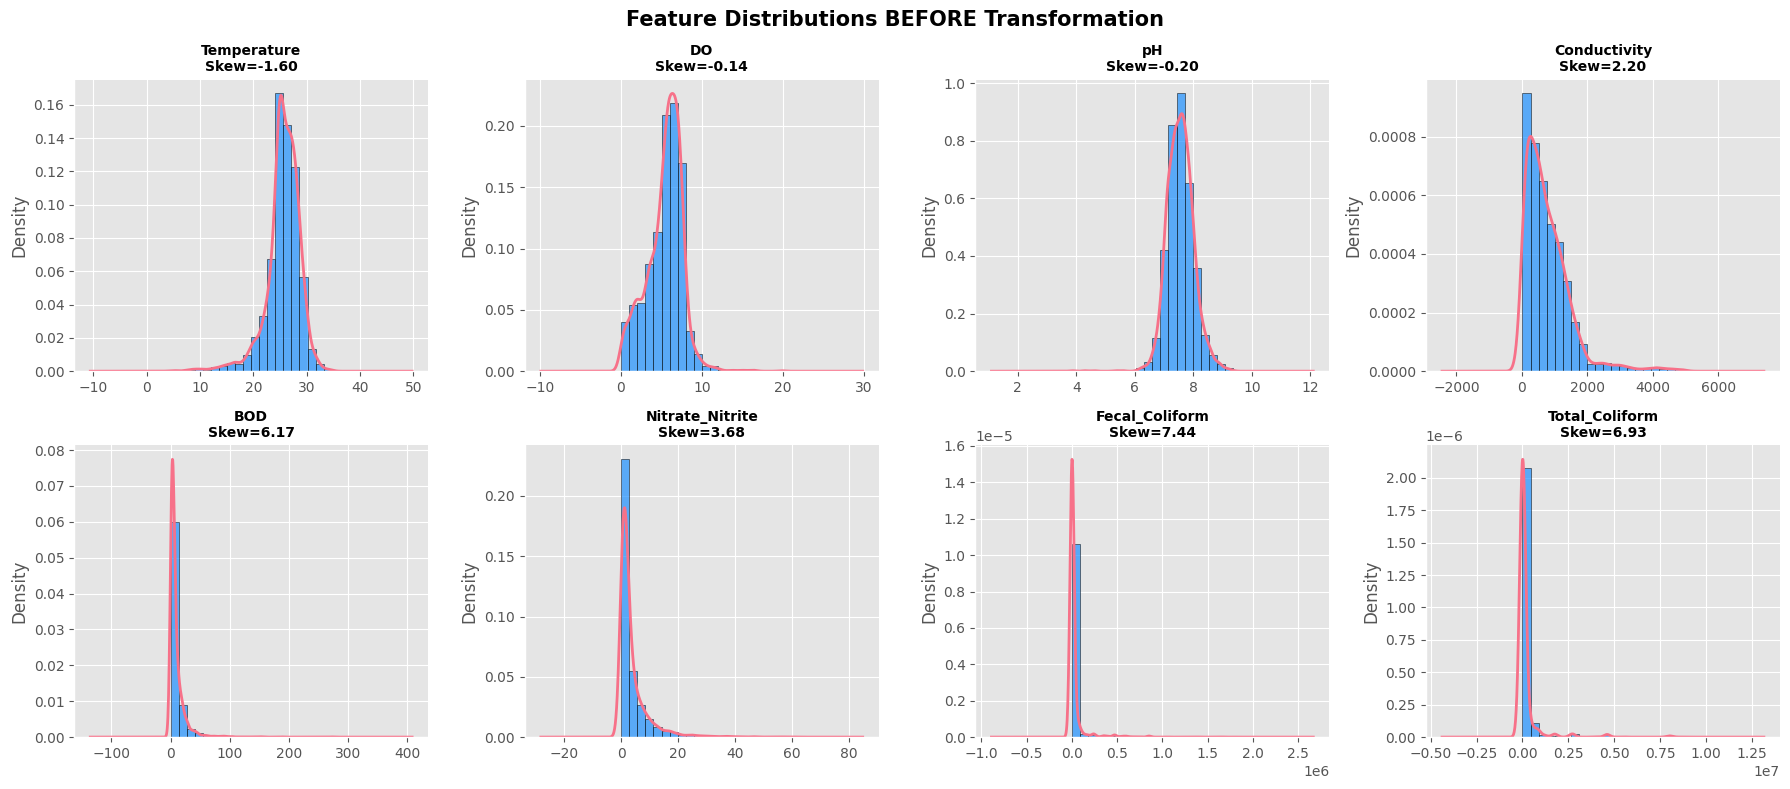

In [107]:
# Before transform
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(FEAT_COLS):
    axes[i].hist(df[col].dropna(), bins=20, color='dodgerblue',
                 edgecolor='black', alpha=0.7, density=True)
    df[col].plot(kind='density', ax=axes[i], linewidth=2)
    axes[i].set_title(f'{col}\nSkew={df[col].skew():.2f}', fontsize=10, fontweight='bold')
    axes[i].spines['top'].set_visible(False); axes[i].spines['right'].set_visible(False)
fig.suptitle('Feature Distributions BEFORE Transformation', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

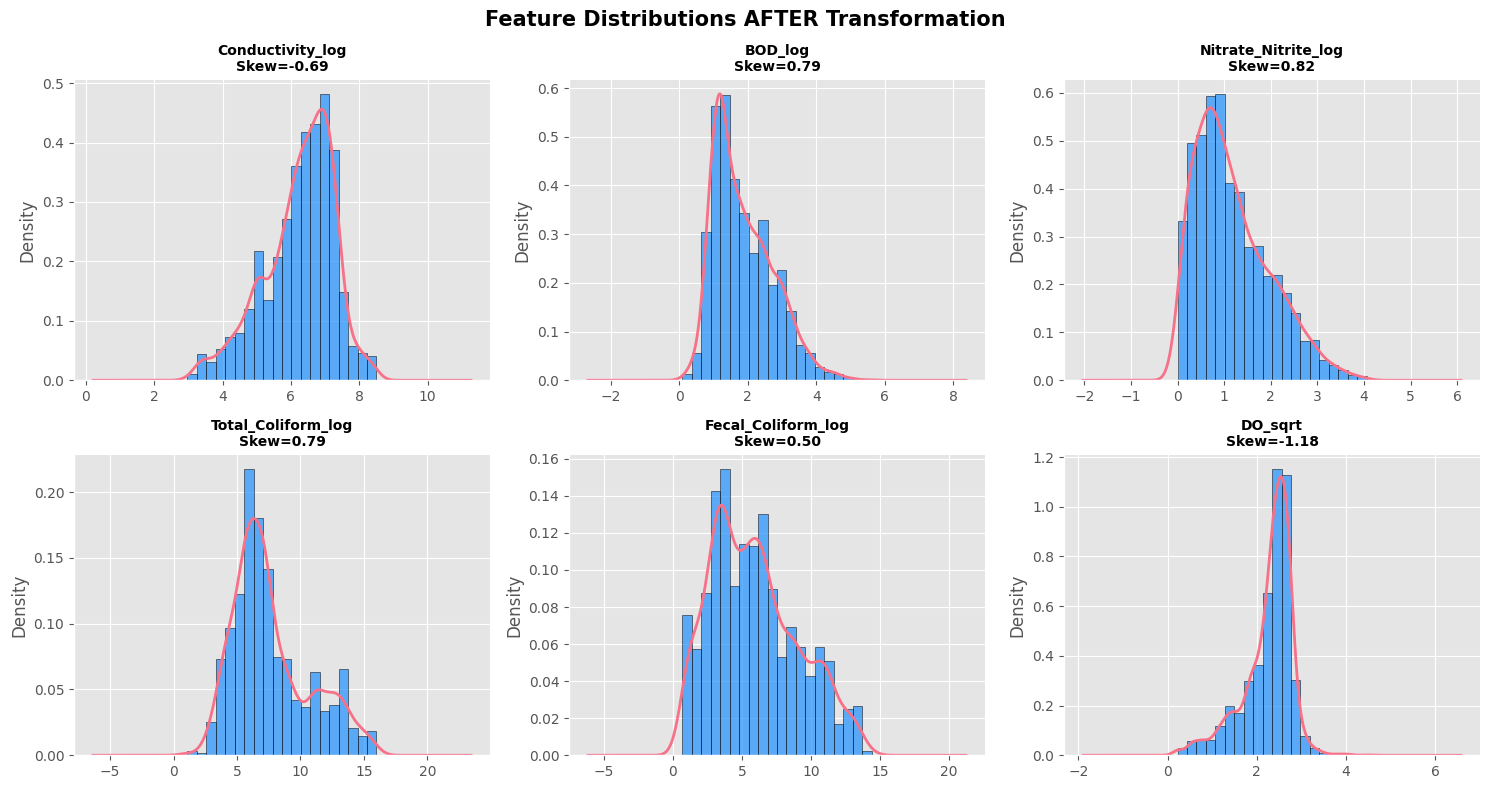

In [25]:
# After transform use log/sqrt versions
TRANSFORM_COLS = ['Conductivity_log', 'BOD_log', 'Nitrate_Nitrite_log',
                  'Total_Coliform_log', 'Fecal_Coliform_log', 'DO_sqrt']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(TRANSFORM_COLS):
    axes[i].hist(df[col].dropna(), bins=20, color='dodgerblue',
                 edgecolor='black', alpha=0.7, density=True)
    df[col].plot(kind='density', ax=axes[i], linewidth=2)
    axes[i].set_title(f'{col}\nSkew={df[col].skew():.2f}', fontsize=10, fontweight='bold')
    axes[i].spines['top'].set_visible(False); axes[i].spines['right'].set_visible(False)
fig.suptitle('Feature Distributions AFTER Transformation', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

## Feature & Target Relationships

In [21]:
# Spearman correlation of all features vs Fecal_Coliform_log
CORR_FEATURES = ['Temperature', 'DO_sqrt', 'pH',
                 'Conductivity_log', 'BOD_log', 'Nitrate_Nitrite_log',
                 'Total_Coliform_log']

rows = []
for col in CORR_FEATURES:
    valid = df[[col, 'Fecal_Coliform_log']].dropna()
    sp_r, sp_p = stats.spearmanr(valid[col], valid['Fecal_Coliform_log'])
    pe_r, _    = stats.pearsonr(valid[col],  valid['Fecal_Coliform_log'])
    rows.append({'Feature': col, 'Spearman ρ': round(sp_r, 3),
                 'Pearson r': round(pe_r, 3), 'p-value': round(sp_p, 4)})

corr_df = pd.DataFrame(rows).sort_values('Spearman ρ', key=abs, ascending=False)
print(" Correlation with Fecal_Coliform_log ")
print(corr_df.to_string(index=False))
print("\n* Total_Coliform shown for EDA insight only excluded from ML features.")

 Correlation with Fecal_Coliform_log 
            Feature  Spearman ρ  Pearson r  p-value
 Total_Coliform_log        0.92       0.94     0.00
            BOD_log        0.37       0.41     0.00
                 pH       -0.17      -0.14     0.00
        Temperature        0.11       0.13     0.00
Nitrate_Nitrite_log        0.04       0.04     0.03
            DO_sqrt       -0.03       0.06     0.15
   Conductivity_log        0.00       0.06     0.92

* Total_Coliform shown for EDA insight only excluded from ML features.


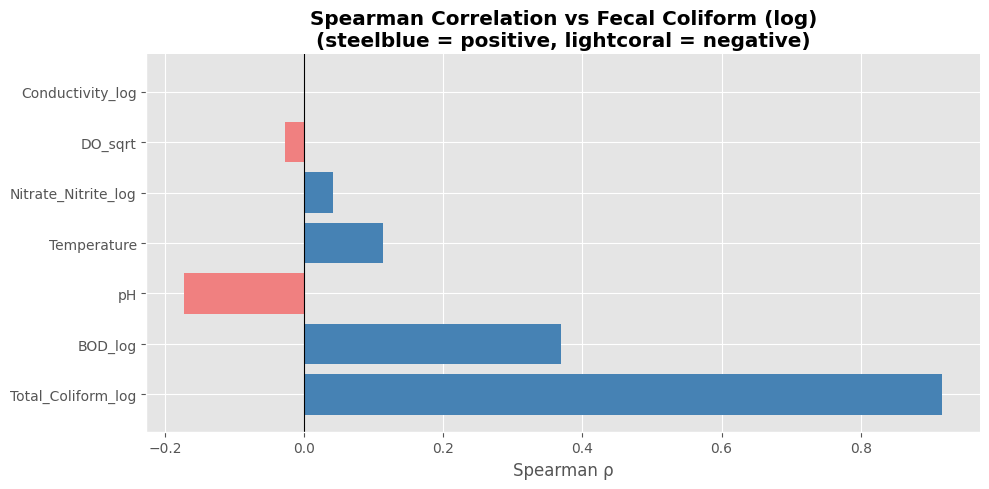

In [22]:
# Correlation bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['steelblue' if v > 0 else 'lightcoral' for v in corr_df['Spearman ρ']]
ax.barh(corr_df['Feature'], corr_df['Spearman ρ'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Spearman Correlation vs Fecal Coliform (log)\n'
             '(steelblue = positive, lightcoral = negative)', fontweight='bold')
ax.set_xlabel('Spearman ρ')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_14824\3254404276.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=temp_bin, y=df['Fecal_Coliform_log'], ax=axes[1],


Pearson r = 0.131  (p = 0.0000)


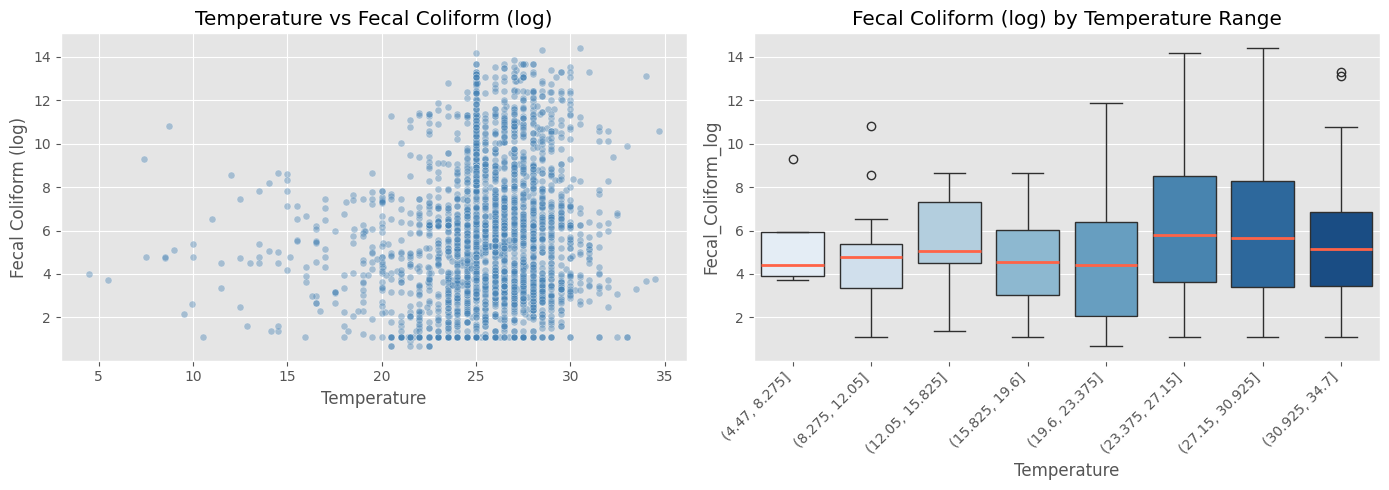

In [23]:
# Scatter + binned boxplot for Temperature (example)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x='Temperature', y='Fecal_Coliform_log', data=df,
                ax=axes[0], alpha=0.4, s=25, color='steelblue')
axes[0].set_title('Temperature vs Fecal Coliform (log)')
axes[0].set_ylabel('Fecal Coliform (log)')

temp_bin = pd.cut(df['Temperature'], bins=8)
sns.boxplot(x=temp_bin, y=df['Fecal_Coliform_log'], ax=axes[1],
            palette='Blues', medianprops=dict(color='tomato', linewidth=2))
axes[1].set_title('Fecal Coliform (log) by Temperature Range')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')

r, p = stats.pearsonr(df['Temperature'], df['Fecal_Coliform_log'])
print(f"Pearson r = {r:.3f}  (p = {p:.4f})")
plt.tight_layout(); plt.show()

## Heatmaps

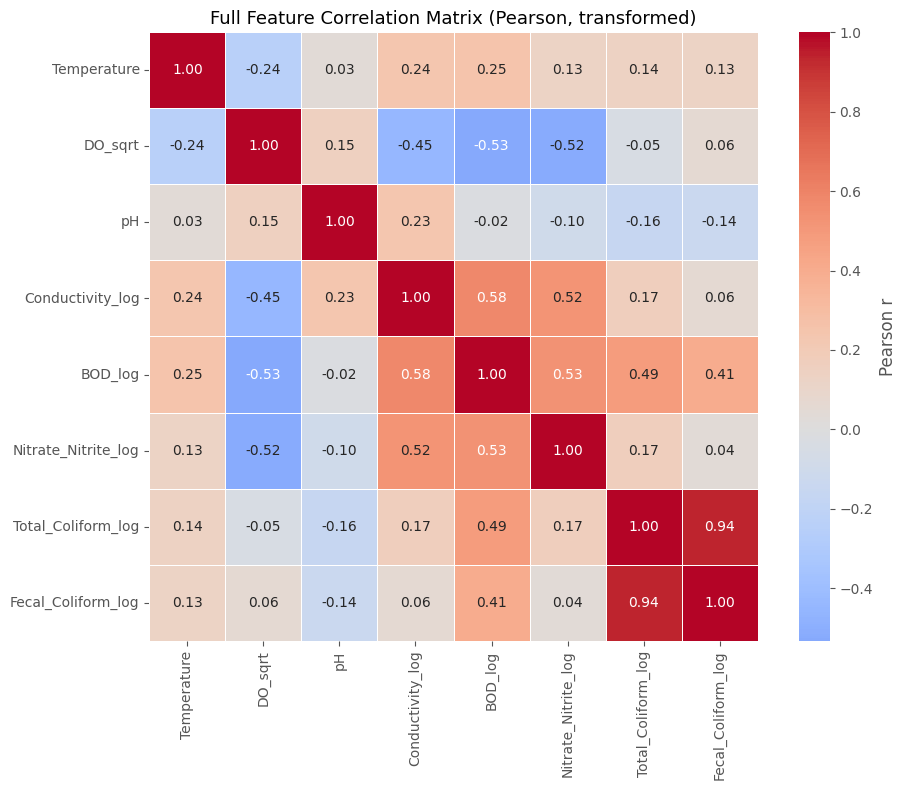

In [24]:
# Full correlation heatmap (log versions)
heat_cols = ['Temperature', 'DO_sqrt', 'pH',
             'Conductivity_log', 'BOD_log', 'Nitrate_Nitrite_log',
             'Total_Coliform_log', 'Fecal_Coliform_log']
corr_mat = df[heat_cols].corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Pearson r'})
plt.title('Full Feature Correlation Matrix (Pearson, transformed)', fontsize=13)
plt.tight_layout(); plt.show()

## EDA Questions

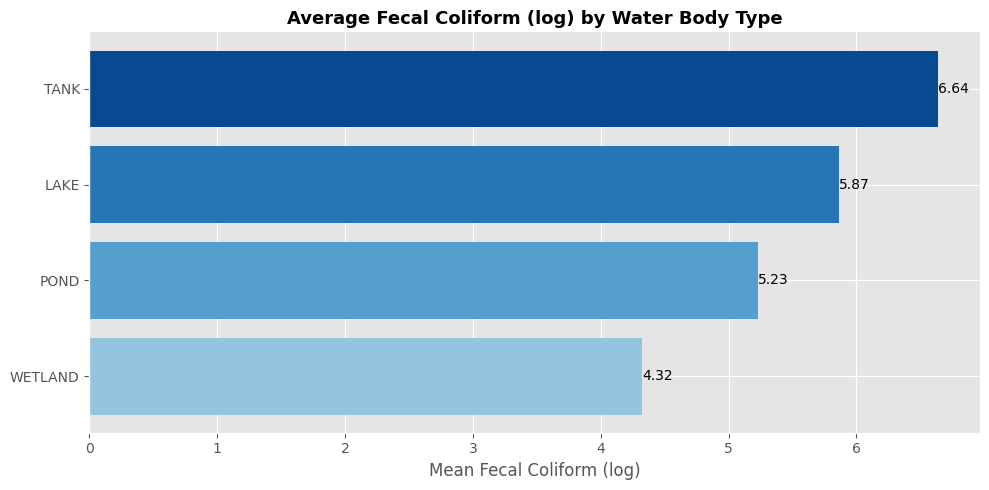

In [25]:
# Q1: Which water body types have the highest contamination?
grouped = (df.groupby('Water_Body_Type')['Fecal_Coliform_log']
           .agg(['mean','count']).query('count >= 10').sort_values('mean'))

colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(grouped)))
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(grouped.index, grouped['mean'], color=colors)
for bar in bars:
    ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}', va='center', ha='left', fontsize=10)
ax.set_title('Average Fecal Coliform (log) by Water Body Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Fecal Coliform (log)')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

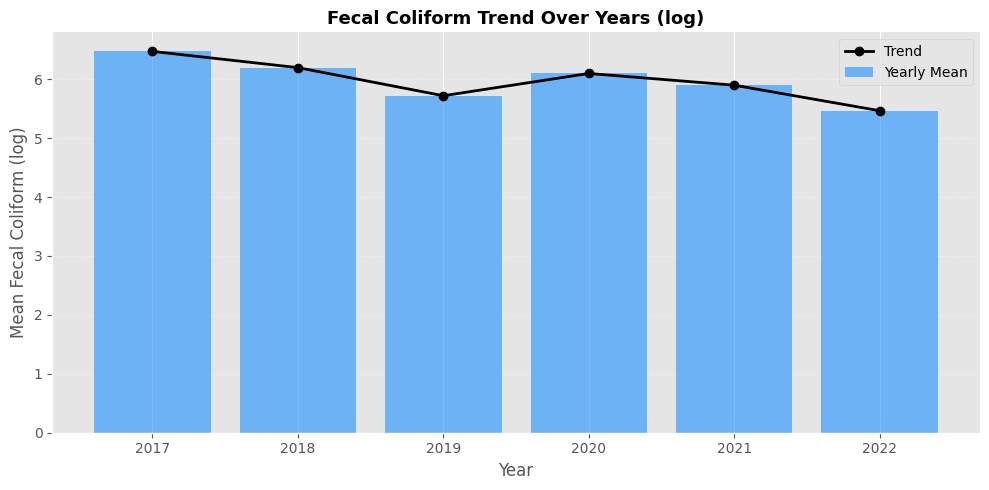

In [26]:
# Q2: Fecal Coliform trend over years
yearly = df.groupby('Year')['Fecal_Coliform_log'].mean().sort_index()
plt.figure(figsize=(10, 5))
plt.bar(yearly.index, yearly.values, color='dodgerblue', alpha=0.6, label='Yearly Mean')
plt.plot(yearly.index, yearly.values, color='black', marker='o', linewidth=2, label='Trend')
plt.title('Fecal Coliform Trend Over Years (log)', fontsize=13, fontweight='bold')
plt.xlabel('Year'); plt.ylabel('Mean Fecal Coliform (log)')
plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.3)
ax = plt.gca()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

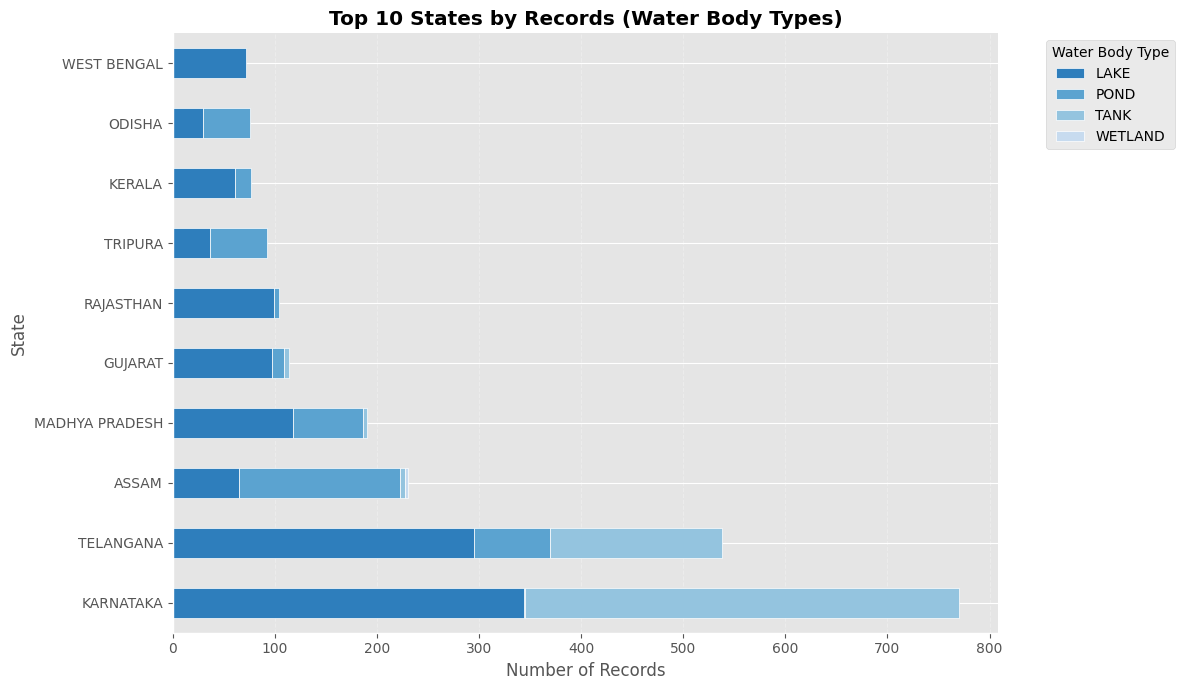

In [27]:
pivot = df.pivot_table(
    index='State_Name',
    columns='Water_Body_Type',
    aggfunc='size',
    fill_value=0
)

# keep top 10 states by total records
top10 = pivot.sum(axis=1).sort_values(ascending=False).head(10).index
pivot = pivot.loc[top10]

# blue palette (steelblue family gradient)
n_types = len(pivot.columns)
blue_colors = plt.cm.Blues_r([0.3 + i*(0.6/max(n_types,1)) for i in range(n_types)])

# plot
fig, ax = plt.subplots(figsize=(12, 7))

pivot.plot(
    kind='barh',
    stacked=True,
    ax=ax,
    color=blue_colors,
    edgecolor='white'
)

ax.set_title('Top 10 States by Records (Water Body Types)', fontweight='bold')
ax.set_xlabel('Number of Records')
ax.set_ylabel('State')

ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(title='Water Body Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Feature Engineering (New Interaction & Temporal Features)

> **Add these before saving `df_ml`.**  
> Three interaction features, log-versions of two, and a simple monsoon indicator.


In [30]:
# NEW FEATURE ENGINEERING (run before saving df_ml)

# 1. Interaction features
df_ml['BOD_Temp']         = df_ml['BOD'] * df_ml['Temperature']
df_ml['BOD_Conductivity'] = df_ml['BOD'] * df_ml['Conductivity']
df_ml['Nitrate_Temp']     = df_ml['Nitrate_Nitrite'] * df_ml['Temperature']

# 2. Log-transformed interaction features (clip to avoid log(0))
df_ml['BOD_Temp_log']         = np.log1p(df_ml['BOD_Temp'].clip(lower=0))
df_ml['BOD_Conductivity_log'] = np.log1p(df_ml['BOD_Conductivity'].clip(lower=0))
print("New features added:")
new_feat_cols = ['BOD_Temp_log', 'BOD_Conductivity_log', 'Nitrate_Temp']
print(new_feat_cols)
print("\ndf_ml shape:", df_ml.shape)


New features added:
['BOD_Temp_log', 'BOD_Conductivity_log', 'Nitrate_Temp']

df_ml shape: (2617, 23)


## Average Fecal-coliform barchart

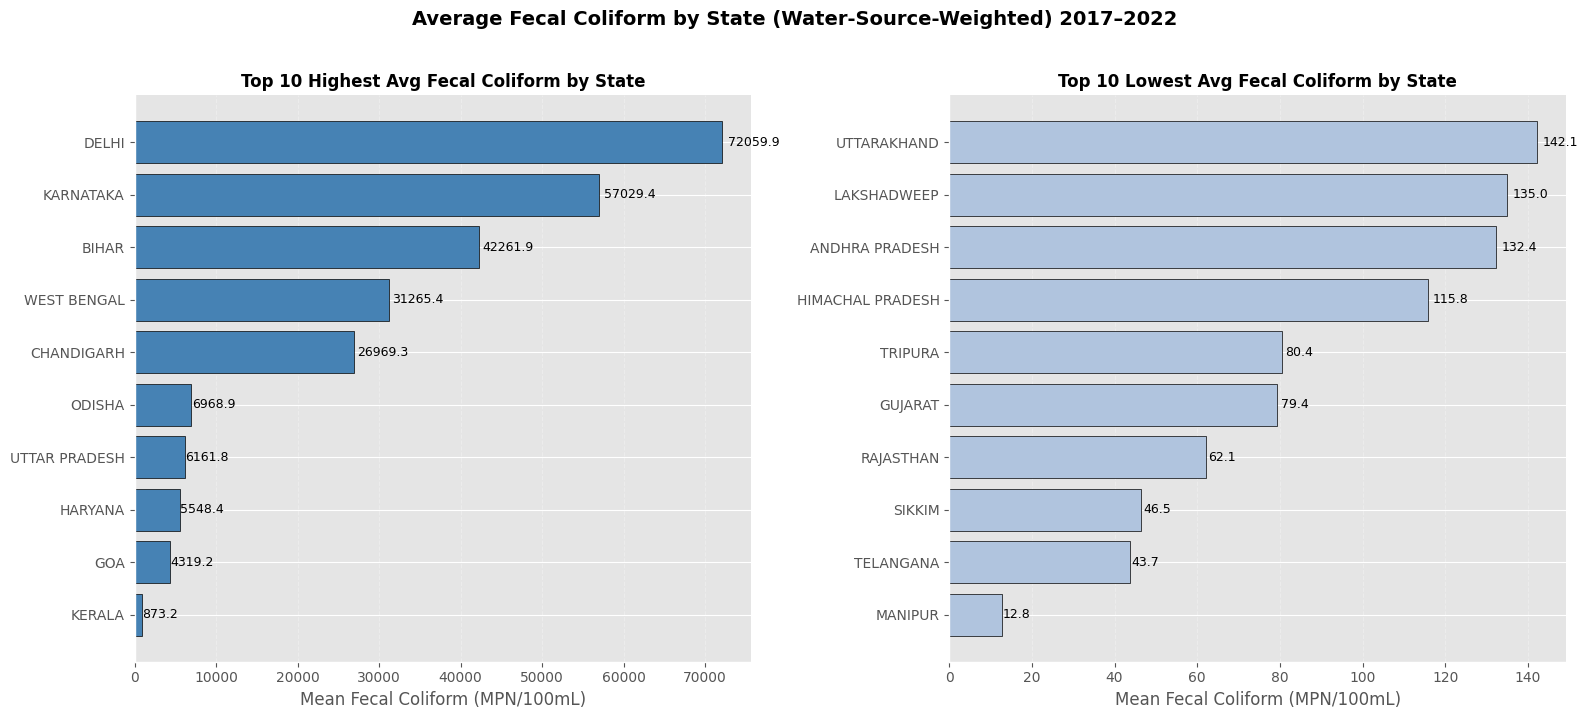

In [31]:
# Average Fecal Coliform by State (water-source-weighted) Top 10 Lowest & Highest

# average within each water body type, per state
state_watertype_avg = (
    df.groupby(['State_Name', 'Water_Body_Type'])['Fecal_Coliform']
    .mean()
    .reset_index()
)

# average those group-means together
state_avg_overall = (
    state_watertype_avg.groupby('State_Name')['Fecal_Coliform']
    .mean()
    .sort_values(ascending=False)
)

top10_highest = state_avg_overall.head(10)
top10_lowest  = state_avg_overall.tail(10).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Highest 10
bars1 = axes[0].barh(top10_highest.index, top10_highest.values,
                      color='steelblue', edgecolor='black')
for bar in bars1:
    axes[0].text(bar.get_width() + bar.get_width()*0.01, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.1f}', va='center', fontsize=9)
axes[0].set_title('Top 10 Highest Avg Fecal Coliform by State', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mean Fecal Coliform (MPN/100mL)')
axes[0].invert_yaxis()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(axis='x', linestyle='--', alpha=0.3)

# Lowest 10
bars2 = axes[1].barh(top10_lowest.index, top10_lowest.values,
                      color='lightsteelblue', edgecolor='black')
for bar in bars2:
    axes[1].text(bar.get_width() + bar.get_width()*0.01, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.1f}', va='center', fontsize=9)
axes[1].set_title('Top 10 Lowest Avg Fecal Coliform by State', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mean Fecal Coliform (MPN/100mL)')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(axis='x', linestyle='--', alpha=0.3)

fig.suptitle('Average Fecal Coliform by State (Water-Source-Weighted) 2017–2022',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

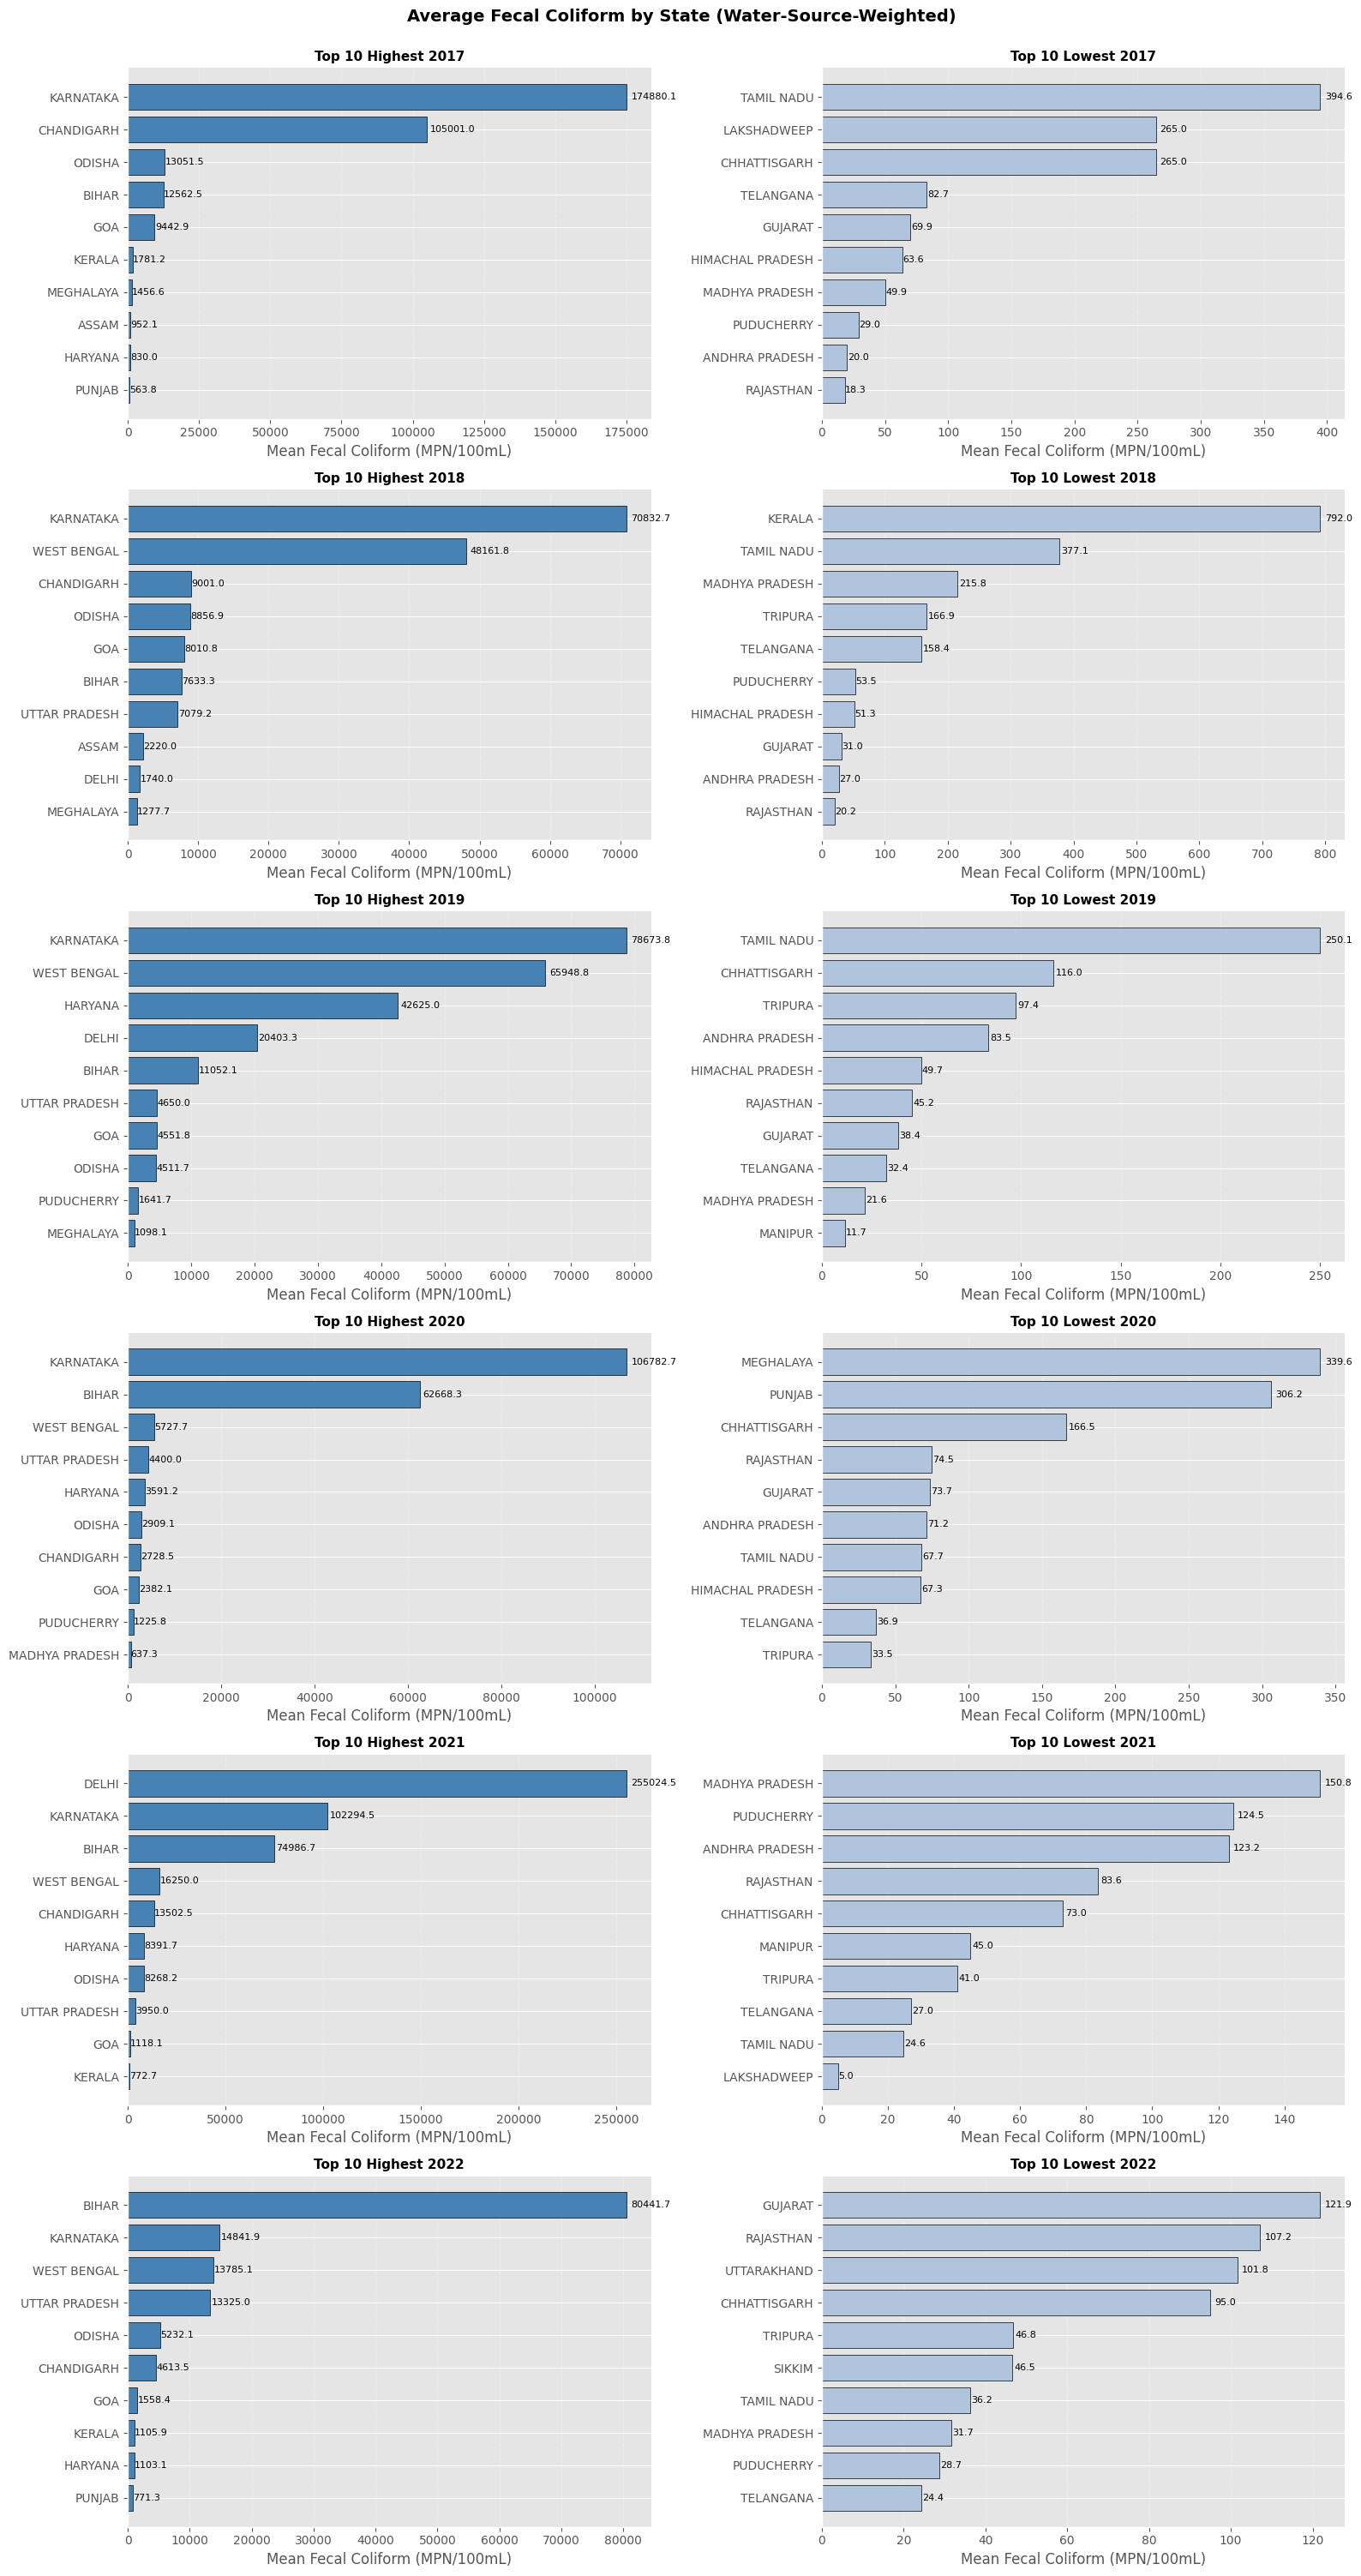

In [32]:
# Average Fecal Coliform by State (water-source-weighted) — Top 10 Lowest & Highest, per Year

# average within each water body type, per state, per year
state_watertype_year_avg = (
    df.groupby(['Year', 'State_Name', 'Water_Body_Type'])['Fecal_Coliform']
    .mean()
    .reset_index()
)

# average those group-means together → one weighted value per state per year
state_year_avg = (
    state_watertype_year_avg.groupby(['Year', 'State_Name'])['Fecal_Coliform']
    .mean()
    .reset_index()
)

years = sorted(state_year_avg['Year'].unique())
fig, axes = plt.subplots(len(years), 2, figsize=(16, 5 * len(years)))
if len(years) == 1:
    axes = [axes]

for row, year in enumerate(years):
    yr_data = state_year_avg[state_year_avg['Year'] == year].set_index('State_Name')['Fecal_Coliform']
    yr_data = yr_data.sort_values(ascending=False)

    top10_highest = yr_data.head(10)
    top10_lowest  = yr_data.tail(10).sort_values(ascending=True)

    # Highest 10
    ax_high = axes[row][0]
    bars1 = ax_high.barh(top10_highest.index, top10_highest.values,
                          color='steelblue', edgecolor='black')
    for bar in bars1:
        ax_high.text(bar.get_width() + bar.get_width()*0.01, bar.get_y() + bar.get_height()/2,
                     f'{bar.get_width():.1f}', va='center', fontsize=8)
    ax_high.set_title(f'Top 10 Highest {year}', fontsize=11, fontweight='bold')
    ax_high.set_xlabel('Mean Fecal Coliform (MPN/100mL)')
    ax_high.invert_yaxis()
    ax_high.spines['top'].set_visible(False)
    ax_high.spines['right'].set_visible(False)
    ax_high.grid(axis='x', linestyle='--', alpha=0.3)

    # Lowest 10
    ax_low = axes[row][1]
    bars2 = ax_low.barh(top10_lowest.index, top10_lowest.values,
                         color='lightsteelblue', edgecolor='black')
    for bar in bars2:
        ax_low.text(bar.get_width() + bar.get_width()*0.01, bar.get_y() + bar.get_height()/2,
                    f'{bar.get_width():.1f}', va='center', fontsize=8)
    ax_low.set_title(f'Top 10 Lowest {year}', fontsize=11, fontweight='bold')
    ax_low.set_xlabel('Mean Fecal Coliform (MPN/100mL)')
    ax_low.spines['top'].set_visible(False)
    ax_low.spines['right'].set_visible(False)
    ax_low.grid(axis='x', linestyle='--', alpha=0.3)

fig.suptitle('Average Fecal Coliform by State (Water-Source-Weighted)',
             fontsize=14, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

## Save Cleaned Dataset

> **What is saved in `df_ml`:**
> - All original feature columns (for reference)
> - All `_log` columns, `DO_sqrt` (recalculated from winsorized values)
> - Winsorizing already applied — ML notebook must NOT re-apply it
> - `Total_Coliform` and `Total_Coliform_log` included for reference (ML will drop them)

In [33]:
import os

# Save path relative to this notebook (or change to your preferred folder)
output_path = "water_quality_cleandataversion.csv"

df_ml.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
print(f"Shape: {df_ml.shape}")
print(f"Columns: {df_ml.columns.tolist()}")


Saved: water_quality_cleandataversion.csv
Shape: (2617, 23)
Columns: ['Water_Body_Type', 'State_Name', 'Year', 'Temperature', 'DO', 'pH', 'Conductivity', 'BOD', 'Nitrate_Nitrite', 'Fecal_Coliform', 'Total_Coliform', 'Conductivity_log', 'BOD_log', 'Nitrate_Nitrite_log', 'Total_Coliform_log', 'Fecal_Coliform_log', 'DO_sqrt', 'BOD_Temp', 'BOD_Conductivity', 'Nitrate_Temp', 'BOD_Temp_log', 'BOD_Conductivity_log', 'Is_Monsoon']
